# Spatial exposure maps for South Sudan

Maps produced here:

1. Farmland (cropland and rangeland cover fraction)
2. Population (WorldPop constrained estimates)
3. Cattle density
4. Flood frequency against population distribution
5. Flood frequency against farmland

The notebook reads from `raw_data/` through the loader functions in `processing_data/` and
writes its output alongside itself in `EDA/exposure/`.

## 1. Setup

This notebook lives in `EDA/exposure/`. The cell below walks up the directory tree until it
finds the repository root, then makes that the working directory, because the loaders in
`processing_data/` use relative paths such as `./raw_data/...`. The notebook's own location
is kept in `NOTEBOOK_DIR` so the export at the end writes back here rather than to the root.

In [2]:
import os
import sys
from pathlib import Path

start = Path.cwd()
repo_root = None
for candidate in [start, *start.parents]:
    if (candidate / "processing_data").is_dir() and (candidate / "raw_data").is_dir():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the repository root. Expected a folder containing both "
        "'processing_data/' and 'raw_data/'."
    )

NOTEBOOK_DIR = start          # where this notebook lives, used for the export at the end
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Every figure and table made below is collected here so the last cell can write them out.
FIGURES = {}
TABLES = {}

print("Working directory:", repo_root)
print("Notebook directory:", NOTEBOOK_DIR)

Working directory: c:\Users\20243565\OneDrive - TU Eindhoven\Documents\Year 3\Capstone Data Challenge - JBG060\JBG060_ZHL_2026_group_12
Notebook directory: c:\Users\20243565\OneDrive - TU Eindhoven\Documents\Year 3\Capstone Data Challenge - JBG060\JBG060_ZHL_2026_group_12\EDA\exposure


In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from rasterio.windows import from_bounds

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

from processing_data.loading import load_flood_masks
from processing_data.loading_impact_data import (
    load_admin_boundaries,
    load_farmland_mask,
    load_cattle,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

### Study area and shared settings

`BBOX` defines the region every map covers. The default is the Sudd floodplain and the
surrounding counties along the White Nile, which is where the flood masks show most activity.
Change the four numbers to move the analysis elsewhere.

`GRID_RES` is the cell size in degrees used when flood detections, population and land cover
are put on a common grid for the paired figures. Roughly 5.5 km at this latitude.

In [4]:
BBOX = {
    "lat_min": 6.5,
    "lat_max": 11.0,
    "lon_min": 28.5,
    "lon_max": 33.0,
}

GRID_RES = 0.05
FLOOD_YEARS = np.arange(2019, 2025)
POP_YEAR = 2024

EXTENT = [BBOX["lon_min"], BBOX["lon_max"], BBOX["lat_min"], BBOX["lat_max"]]

admin1, admin2 = load_admin_boundaries()
print(f"{len(admin1)} states, {len(admin2)} counties loaded")

10 states, 79 counties loaded


In [5]:
def draw_admin(ax, level2=True, color="0.25", lw=0.4):
    """Outline states, and optionally counties, on top of a raster axis."""
    if level2:
        admin2.boundary.plot(ax=ax, color=color, linewidth=lw * 0.6, alpha=0.5)
    admin1.boundary.plot(ax=ax, color=color, linewidth=lw * 2.0)


def style_map(ax, title):
    ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
    ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
    ax.set_xlabel("Longitude (deg E)")
    ax.set_ylabel("Latitude (deg N)")
    ax.set_title(title)
    ax.set_aspect("equal")

## 2. Farmland map

`load_farmland_mask` returns the ASAP cover masks: each pixel is the percentage of its area
covered by cropland or by rangeland, at roughly 500 m resolution. The two masks are drawn
side by side, then combined into a single categorical map showing which land use dominates.

In [6]:
crop = load_farmland_mask(BBOX, "crop")
rangeland = load_farmland_mask(BBOX, "rangeland")

print("crop mask     :", crop.shape, "max", float(np.nanmax(crop)))
print("rangeland mask:", rangeland.shape, "max", float(np.nanmax(rangeland)))

crop mask     : (1008, 1008) max 100.0
rangeland mask: (1008, 1008) max 100.0


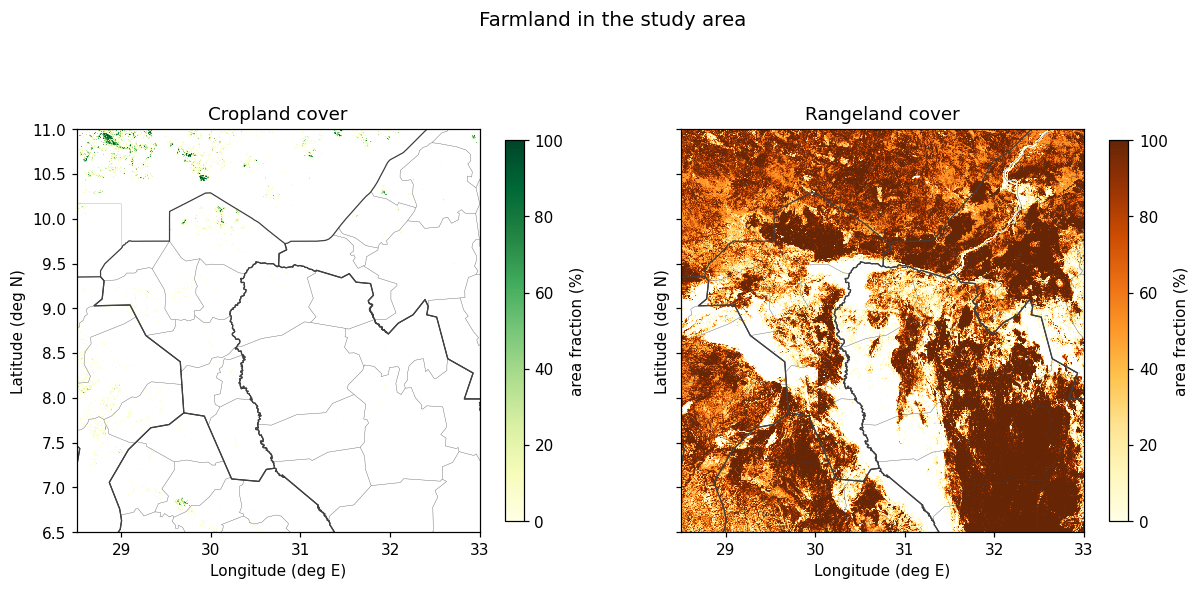

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, da, title, cmap in [
    (axes[0], crop, "Cropland cover", "YlGn"),
    (axes[1], rangeland, "Rangeland cover", "YlOrBr"),
]:
    im = ax.imshow(
        np.where(da.values > 0, da.values, np.nan),
        extent=EXTENT,
        origin="upper",
        cmap=cmap,
        vmin=0,
        vmax=100,
        interpolation="nearest",
    )
    draw_admin(ax)
    style_map(ax, title)
    fig.colorbar(im, ax=ax, shrink=0.75, label="area fraction (%)")

fig.suptitle("Farmland in the study area", y=0.98, fontsize=13)
FIGURES["01_farmland_crop_rangeland"] = fig
plt.show()

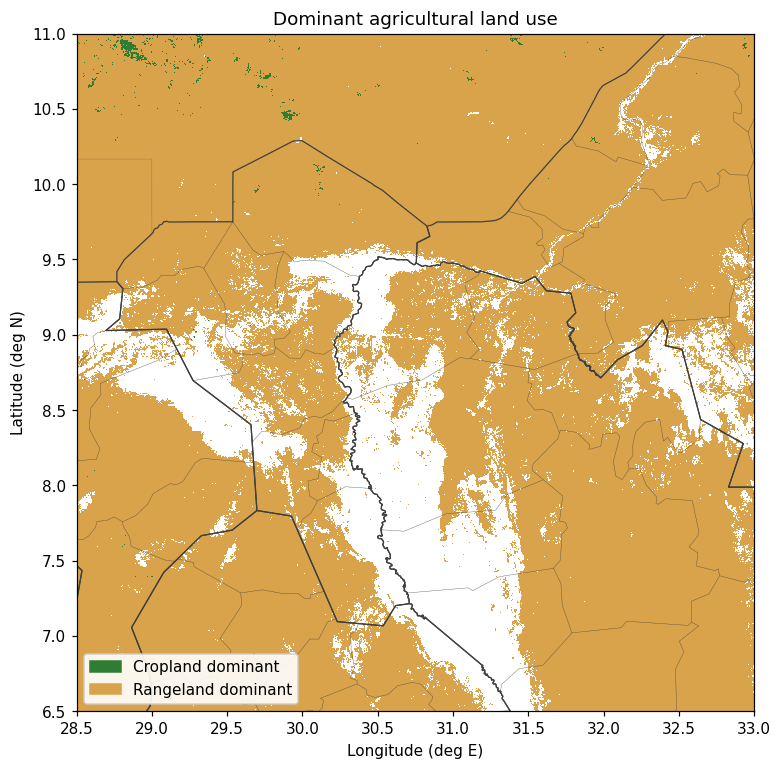

Cropland dominates 0.3% of the vegetated cells in the box


In [8]:
crop_v = crop.values
range_v = rangeland.values

# Same window and resolution for both masks, so they align cell by cell.
assert crop_v.shape == range_v.shape

MIN_COVER = 5  # ignore cells with only a trace of either cover type

dominant = np.full(crop_v.shape, np.nan)
has_crop = crop_v >= MIN_COVER
has_range = range_v >= MIN_COVER

dominant[has_range & ~has_crop] = 0
dominant[has_crop & ~has_range] = 1
dominant[has_crop & has_range] = np.where(
    crop_v[has_crop & has_range] >= range_v[has_crop & has_range], 1, 0
)

fig, ax = plt.subplots(figsize=(9, 8))
cmap = ListedColormap(["#d8a34a", "#2f7d32"])
ax.imshow(dominant, extent=EXTENT, origin="upper", cmap=cmap, vmin=0, vmax=1,
          interpolation="nearest")
draw_admin(ax)
style_map(ax, "Dominant agricultural land use")

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#2f7d32", label="Cropland dominant"),
    plt.Rectangle((0, 0), 1, 1, color="#d8a34a", label="Rangeland dominant"),
]
ax.legend(handles=handles, loc="lower left", framealpha=0.9)
FIGURES["02_farmland_dominant_landuse"] = fig
plt.show()

share_crop = np.nansum(dominant == 1) / np.isfinite(dominant).sum()
print(f"Cropland dominates {share_crop:.1%} of the vegetated cells in the box")

## 3. Population map

WorldPop constrained estimates, 100 m grid, people per pixel. The raster is read through a
window so only the study area is pulled into memory. Counts span several orders of magnitude,
so the colour scale is logarithmic and empty pixels are left blank.

In [9]:
def read_worldpop(year, bbox):
    """Read the WorldPop raster for one year, clipped to the bounding box."""
    fname = f"./raw_data/worldpop/ssd_pop_{year}_CN_100m_R2025A_v1.tif"
    with rasterio.open(fname) as src:
        window = from_bounds(
            bbox["lon_min"], bbox["lat_min"],
            bbox["lon_max"], bbox["lat_max"],
            src.transform,
        )
        arr = src.read(1, window=window).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        transform = rasterio.windows.transform(window, src.transform)
    arr[arr < 0] = np.nan
    return arr, transform


pop, pop_transform = read_worldpop(POP_YEAR, BBOX)
print("raster shape:", pop.shape)
print(f"total population in box ({POP_YEAR}): {np.nansum(pop):,.0f}")

raster shape: (5400, 5400)
total population in box (2024): 4,604,107


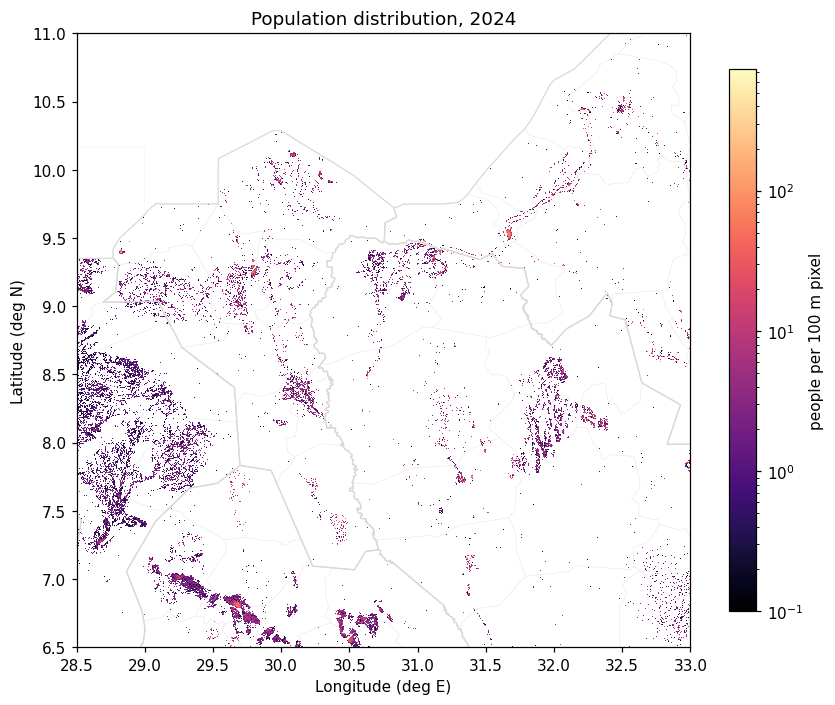

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))

vis = np.where(pop > 0, pop, np.nan)
im = ax.imshow(
    vis,
    extent=EXTENT,
    origin="upper",
    cmap="magma",
    norm=LogNorm(vmin=0.1, vmax=max(np.nanmax(vis), 1.0)),
    interpolation="nearest",
)
draw_admin(ax, color="0.85")
style_map(ax, f"Population distribution, {POP_YEAR}")
fig.colorbar(im, ax=ax, shrink=0.8, label="people per 100 m pixel")
FIGURES["03_population_map"] = fig
plt.show()

### Population trend

Totals inside the same box for every year the product covers, as a check that the raster
window is being read consistently.

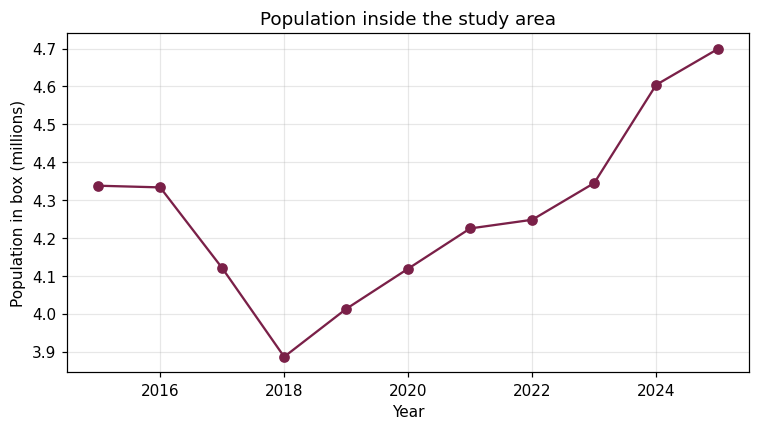

,population
year,
2015,"4,337,796"
2016,"4,333,370"
2017,"4,120,424"
2018,"3,886,156"
2019,"4,012,594"
2020,"4,118,846"
2021,"4,225,020"
2022,"4,247,889"
2023,"4,344,799"


In [11]:
years_pop = np.arange(2015, 2026)
totals = {}
for y in years_pop:
    arr, _ = read_worldpop(y, BBOX)
    totals[y] = float(np.nansum(arr))
    del arr

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(totals), [v / 1e6 for v in totals.values()], marker="o", color="#7a2048")
ax.set_xlabel("Year")
ax.set_ylabel("Population in box (millions)")
ax.set_title("Population inside the study area")
ax.grid(alpha=0.3)
FIGURES["04_population_trend"] = fig
plt.show()

pop_trend = pd.Series(totals, name="population").rename_axis("year").to_frame()
TABLES["population_trend"] = pop_trend
pop_trend.style.format("{:,.0f}")

## 4. Cattle map

Pixel level cattle counts for the Greater Horn of Africa. `load_cattle` returns the full
raster as a DataFrame indexed by latitude with longitude columns, so it is clipped to the
study area before plotting.

In [12]:
cattle_df, cattle_lons, cattle_lats = load_cattle()

lon_sel = (cattle_lons >= BBOX["lon_min"]) & (cattle_lons <= BBOX["lon_max"])
lat_sel = (cattle_lats >= BBOX["lat_min"]) & (cattle_lats <= BBOX["lat_max"])

cattle_box = cattle_df.loc[lat_sel, lon_sel]
cattle_arr = cattle_box.values.astype(np.float32)

# Rows follow the raster order, which runs north to south.
if cattle_box.index.values[0] < cattle_box.index.values[-1]:
    cattle_arr = cattle_arr[::-1]

print("cattle grid:", cattle_arr.shape)
print(f"total head of cattle in box: {np.nansum(cattle_arr):,.0f}")

cattle grid: (54, 54)
total head of cattle in box: 5,770,473


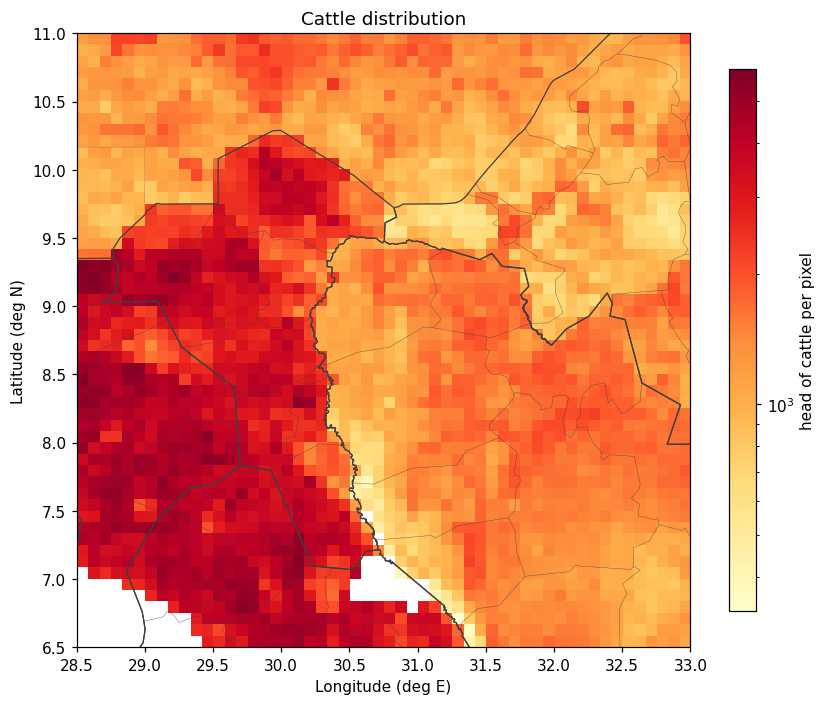

In [13]:
fig, ax = plt.subplots(figsize=(9, 8))

vis = np.where(cattle_arr > 0, cattle_arr, np.nan)
im = ax.imshow(
    vis,
    extent=EXTENT,
    origin="upper",
    cmap="YlOrRd",
    norm=LogNorm(vmin=max(np.nanmin(vis), 0.1), vmax=np.nanmax(vis)),
    interpolation="nearest",
)
draw_admin(ax)
style_map(ax, "Cattle distribution")
fig.colorbar(im, ax=ax, shrink=0.8, label="head of cattle per pixel")
FIGURES["05_cattle_map"] = fig
plt.show()

## 5. Flood frequency

`load_flood_masks` returns one row per detected flooded pixel per 3-day composite. Flood
frequency here is the number of composites in which a cell was flagged, divided by the number
of years loaded, so the value reads as detections per year.

Detections are binned onto the `GRID_RES` grid, because the native pixel size of about 232 m
is far finer than anything the population or land cover comparison needs.

In [14]:
floods = load_flood_masks(FLOOD_YEARS, bbox=BBOX)

print(f"{len(floods):,} detections between {FLOOD_YEARS[0]} and {FLOOD_YEARS[-1]}")
print(f"  recurring: {(floods['flood_type'] == 0).sum():,}")
print(f"  unusual  : {(floods['flood_type'] == 1).sum():,}")
floods.head()

35,189,005 detections between 2019 and 2024
  recurring: 1,959,267
  unusual  : 33,229,738


,date,lat,lon,tile,flood_type
0,2019-01-01,6.509375,31.398958,h21v08,0
1,2019-01-01,6.511458,31.398958,h21v08,0
2,2019-01-01,6.513542,31.405209,h21v08,0
3,2019-01-01,6.515625,31.403126,h21v08,0
4,2019-01-01,6.534375,31.392708,h21v08,0


In [15]:
lon_edges = np.arange(BBOX["lon_min"], BBOX["lon_max"] + GRID_RES, GRID_RES)
lat_edges = np.arange(BBOX["lat_min"], BBOX["lat_max"] + GRID_RES, GRID_RES)


def bin_detections(df):
    """Count detections per grid cell and return an array in north-up orientation."""
    counts, _, _ = np.histogram2d(
        df["lat"].values, df["lon"].values, bins=[lat_edges, lon_edges]
    )
    return counts[::-1]


n_years = len(FLOOD_YEARS)
freq_all = bin_detections(floods) / n_years
freq_unusual = bin_detections(floods[floods["flood_type"] == 1]) / n_years
freq_recurring = bin_detections(floods[floods["flood_type"] == 0]) / n_years

print("grid shape:", freq_all.shape)

grid shape: (91, 90)


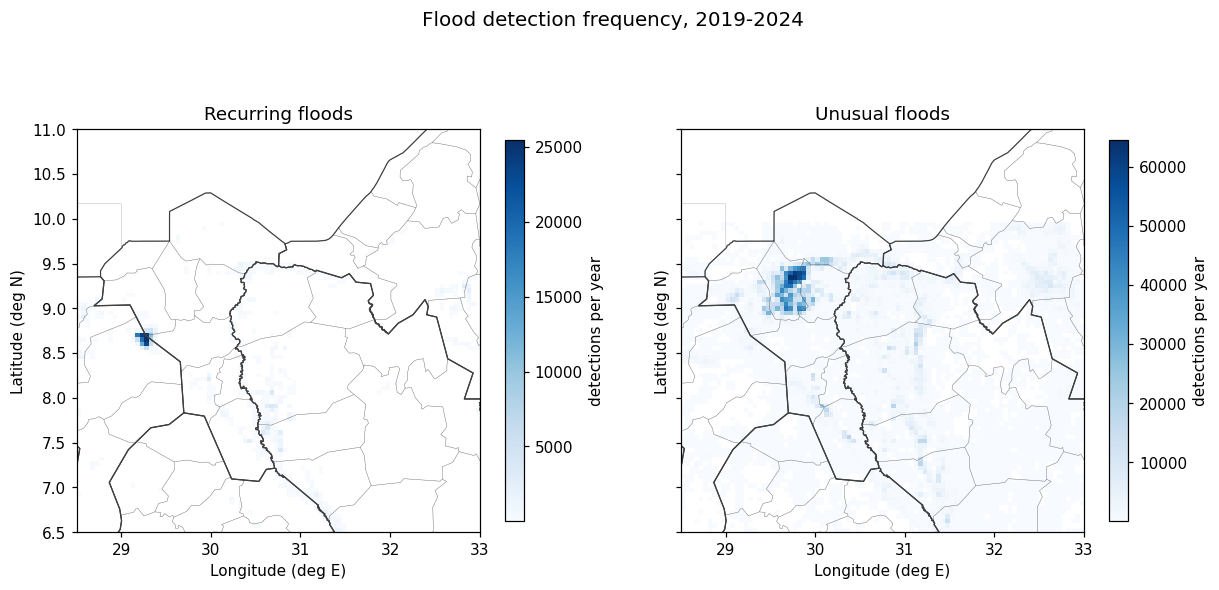

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, grid, title in [
    (axes[0], freq_recurring, "Recurring floods"),
    (axes[1], freq_unusual, "Unusual floods"),
]:
    im = ax.imshow(
        np.where(grid > 0, grid, np.nan),
        extent=EXTENT,
        origin="upper",
        cmap="Blues",
        interpolation="nearest",
    )
    draw_admin(ax)
    style_map(ax, title)
    fig.colorbar(im, ax=ax, shrink=0.75, label="detections per year")

fig.suptitle(f"Flood detection frequency, {FLOOD_YEARS[0]}-{FLOOD_YEARS[-1]}", y=0.98,
             fontsize=13)
FIGURES["06_flood_frequency_recurring_vs_unusual"] = fig
plt.show()

## 6. Flood frequency against population

The two panels share the same axes and the same grid, so a cell in the upper panel sits
directly above the population of that cell in the lower panel. Population is summed from the
100 m raster into the flood grid.

In [23]:
def regrid_to_flood_grid(arr, src_extent):
    """Sum a finer raster into the flood frequency grid.

    Cell centres of the source raster are assigned to grid cells with histogram2d,
    weighted by the raster value.
    """
    lon_min, lon_max, lat_min, lat_max = src_extent
    n_rows, n_cols = arr.shape

    lons = np.linspace(lon_min, lon_max, n_cols, endpoint=False) + (lon_max - lon_min) / (2 * n_cols)
    lats = np.linspace(lat_max, lat_min, n_rows, endpoint=False) - (lat_max - lat_min) / (2 * n_rows)

    lon_grid, lat_grid = np.meshgrid(lons, lats)
    values = np.nan_to_num(arr, nan=0.0)

    out, _, _ = np.histogram2d(
        lat_grid.ravel(), lon_grid.ravel(),
        bins=[lat_edges, lon_edges],
        weights=values.ravel(),
    )
    return out[::-1]


pop_grid = regrid_to_flood_grid(pop, EXTENT)
print(f"population on flood grid: {pop_grid.sum():,.0f} people "
      f"(raster total {np.nansum(pop):,.0f})")

population on flood grid: 4,604,107 people (raster total 4,604,107)


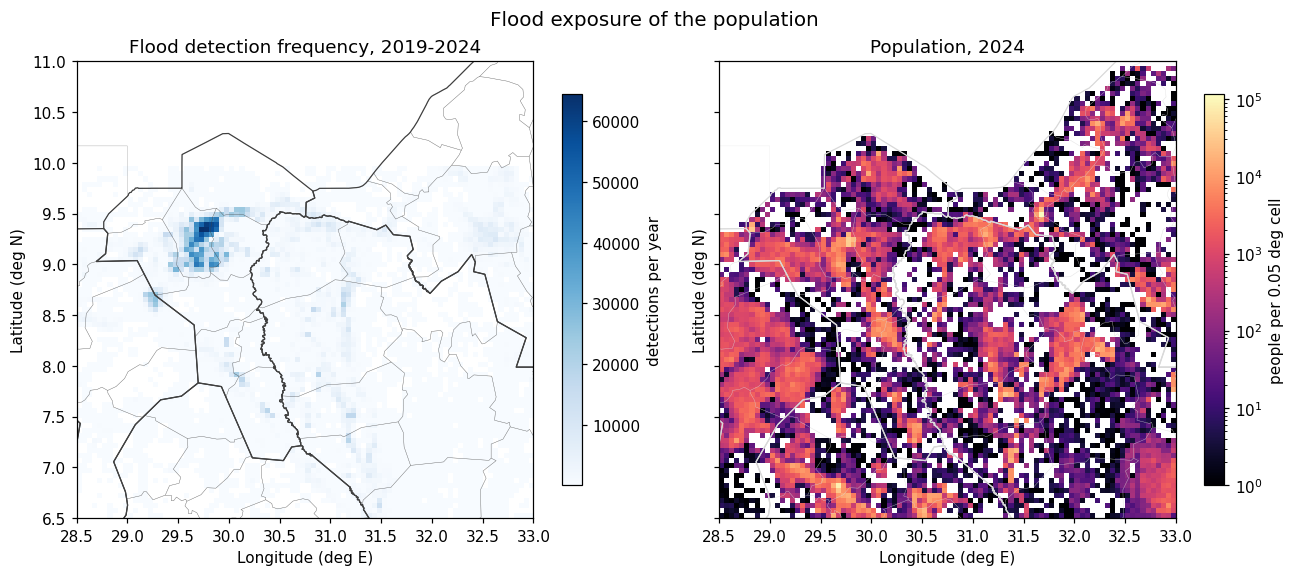

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

im0 = axes[0].imshow(
    np.where(freq_all > 0, freq_all, np.nan),
    extent=EXTENT, origin="upper", cmap="Blues", interpolation="nearest",
)
draw_admin(axes[0])
style_map(axes[0], f"Flood detection frequency, {FLOOD_YEARS[0]}-{FLOOD_YEARS[-1]}")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="detections per year")

im1 = axes[1].imshow(
    np.where(pop_grid > 0, pop_grid, np.nan),
    extent=EXTENT, origin="upper", cmap="magma",
    norm=LogNorm(vmin=1, vmax=max(pop_grid.max(), 10)),
    interpolation="nearest",
)
draw_admin(axes[1], color="0.85")
style_map(axes[1], f"Population, {POP_YEAR}")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label=f"people per {GRID_RES} deg cell")

fig.suptitle("Flood exposure of the population", y=0.995, fontsize=13)
plt.tight_layout()
FIGURES["07_flood_frequency_vs_population"] = fig
plt.show()

### How much of the population sits in frequently flooded cells

Cells are grouped by how often they are flagged, and the population living in each group is
summed. This puts a number on what the paired maps show.

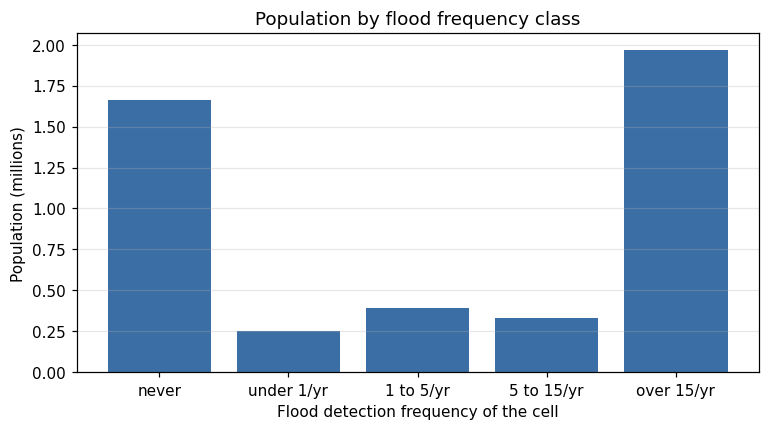

,population,cells,share of population
group,,,
never,"1,659,634",3390,36.0%
under 1/yr,"254,307",714,5.5%
1 to 5/yr,"390,301",832,8.5%
5 to 15/yr,"329,093",637,7.1%
over 15/yr,"1,970,772",2617,42.8%


In [35]:
bins = [0, 0.001, 1, 5, 15, np.inf]
labels = ["never", "under 1/yr", "1 to 5/yr", "5 to 15/yr", "over 15/yr"]

group = pd.cut(freq_all.ravel(), bins=bins, labels=labels, right=False)
summary = (
    pd.DataFrame({"group": group, "population": pop_grid.ravel()})
    .groupby("group", observed=False)["population"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "population", "count": "cells"})
)
summary["share of population"] = summary["population"] / summary["population"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary.index.astype(str), summary["population"] / 1e6, color="#3b6ea5")
ax.set_ylabel("Population (millions)")
ax.set_xlabel("Flood detection frequency of the cell")
ax.set_title("Population by flood frequency class")
ax.grid(axis="y", alpha=0.3)
FIGURES["08_population_by_flood_class"] = fig
plt.show()

TABLES["population_by_flood_class"] = summary
summary.style.format({"population": "{:,.0f}", "share of population": "{:.1%}"})

## 7. Flood frequency against farmland

Same layout, with cropland cover in place of population. The lower panel shows the mean
cropland fraction per grid cell, so a value of 30 means roughly a third of that cell is
cultivated.

In [36]:
def mean_to_flood_grid(arr, src_extent):
    """Average a finer raster into the flood frequency grid."""
    total = regrid_to_flood_grid(arr, src_extent)
    counts = regrid_to_flood_grid(np.isfinite(arr).astype(np.float32), src_extent)
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.where(counts > 0, total / counts, np.nan)
    return out


crop_grid = mean_to_flood_grid(crop.values.astype(np.float32), EXTENT)
range_grid = mean_to_flood_grid(rangeland.values.astype(np.float32), EXTENT)

print("mean cropland cover on grid:", np.nanmean(crop_grid).round(2), "%")

mean cropland cover on grid: 0.38 %


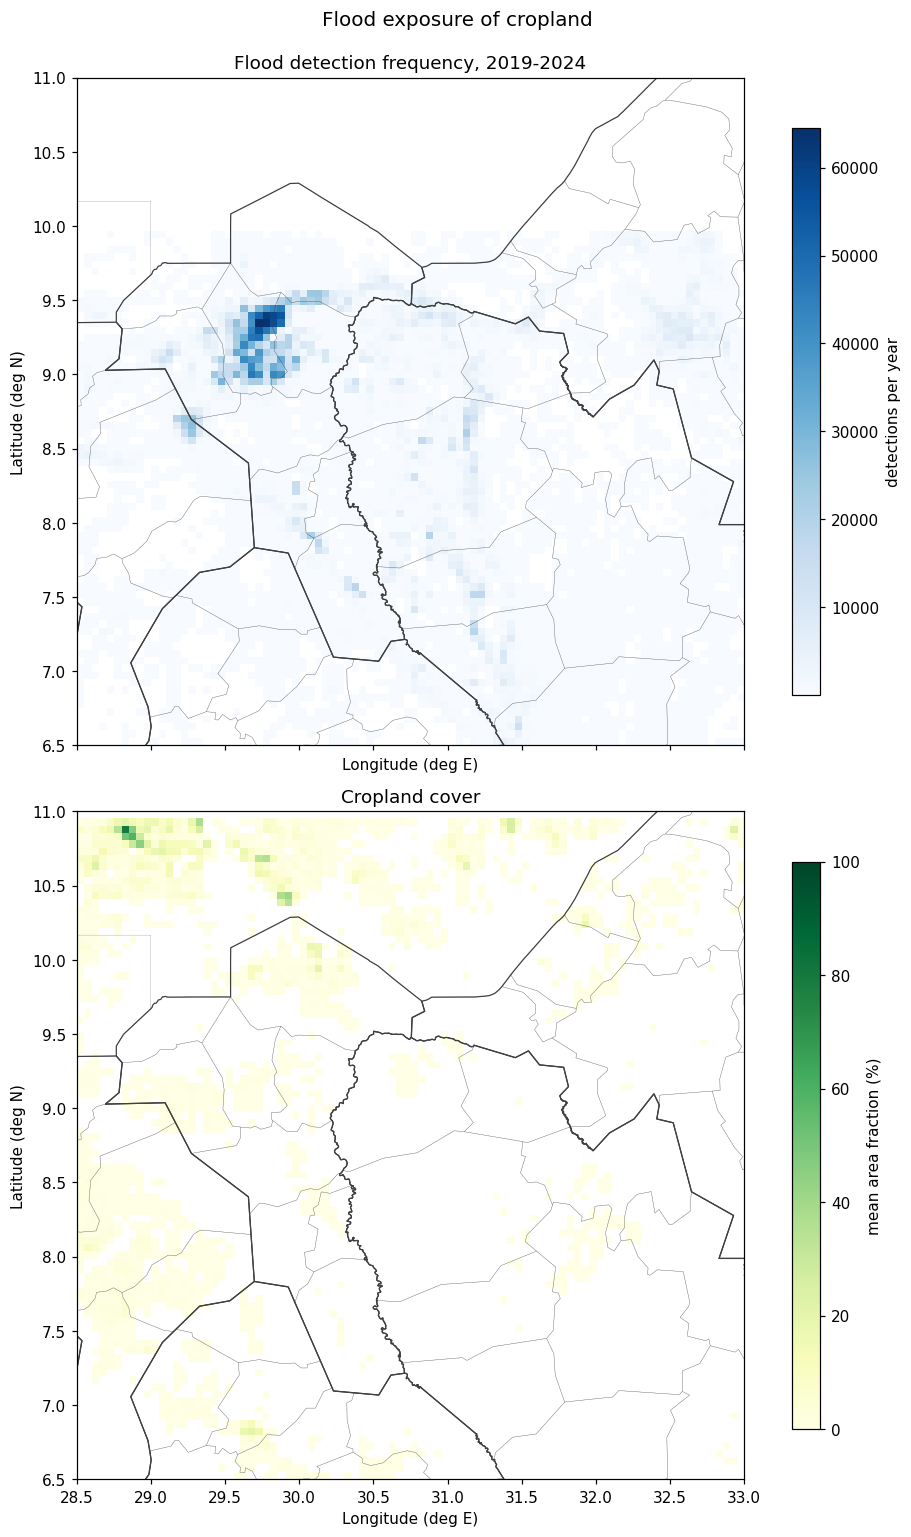

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(9, 14), sharex=True, sharey=True)

im0 = axes[0].imshow(
    np.where(freq_all > 0, freq_all, np.nan),
    extent=EXTENT, origin="upper", cmap="Blues", interpolation="nearest",
)
draw_admin(axes[0])
style_map(axes[0], f"Flood detection frequency, {FLOOD_YEARS[0]}-{FLOOD_YEARS[-1]}")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="detections per year")

im1 = axes[1].imshow(
    np.where(crop_grid > 0, crop_grid, np.nan),
    extent=EXTENT, origin="upper", cmap="YlGn", vmin=0, vmax=100,
    interpolation="nearest",
)
draw_admin(axes[1])
style_map(axes[1], "Cropland cover")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label="mean area fraction (%)")

fig.suptitle("Flood exposure of cropland", y=0.995, fontsize=13)
plt.tight_layout()
FIGURES["09_flood_frequency_vs_farmland"] = fig
plt.show()

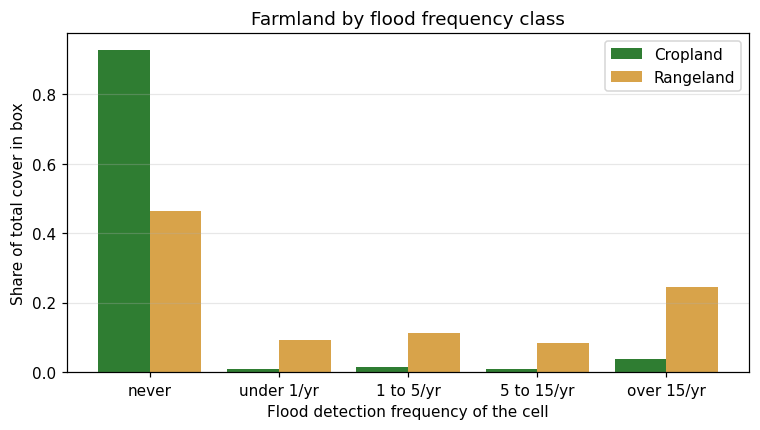

,cropland,rangeland
group,,
never,92.9%,46.3%
under 1/yr,0.9%,9.3%
1 to 5/yr,1.4%,11.4%
5 to 15/yr,1.0%,8.4%
over 15/yr,3.9%,24.5%


In [38]:
crop_area_proxy = np.nan_to_num(crop_grid, nan=0.0)
range_area_proxy = np.nan_to_num(range_grid, nan=0.0)

group = pd.cut(freq_all.ravel(), bins=bins, labels=labels, right=False)
land_summary = (
    pd.DataFrame({
        "group": group,
        "cropland": crop_area_proxy.ravel(),
        "rangeland": range_area_proxy.ravel(),
    })
    .groupby("group", observed=False)[["cropland", "rangeland"]]
    .sum()
)
land_summary = land_summary.div(land_summary.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(land_summary))
ax.bar(x - 0.2, land_summary["cropland"], width=0.4, label="Cropland", color="#2f7d32")
ax.bar(x + 0.2, land_summary["rangeland"], width=0.4, label="Rangeland", color="#d8a34a")
ax.set_xticks(x)
ax.set_xticklabels(land_summary.index.astype(str))
ax.set_ylabel("Share of total cover in box")
ax.set_xlabel("Flood detection frequency of the cell")
ax.set_title("Farmland by flood frequency class")
ax.legend()
ax.grid(axis="y", alpha=0.3)
FIGURES["10_farmland_by_flood_class"] = fig
plt.show()

TABLES["farmland_by_flood_class"] = land_summary
land_summary.style.format("{:.1%}")

## 8. Export

Writes every figure and table produced above next to this notebook, in
`EDA/exposure/`. Everything lands flat in that one folder, no subdirectories.

Figures are written as PNG, tables as CSV and as a single Excel workbook. The gridded arrays
go out too, so the maps can be redrawn without reloading the flood masks, which is the slow
step. Set `SAVE_PDF` to `True` if vector copies are needed for the report.

Run this after the rest of the notebook, since it exports what is held in `FIGURES` and
`TABLES`.

In [39]:
EXPORT_DIR = NOTEBOOK_DIR
SAVE_PDF = False

written = []

# Figures
for name, fig in FIGURES.items():
    path = EXPORT_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    written.append(path)

    if SAVE_PDF:
        path = EXPORT_DIR / f"{name}.pdf"
        fig.savefig(path, bbox_inches="tight")
        written.append(path)

# Tables
for name, table in TABLES.items():
    path = EXPORT_DIR / f"table_{name}.csv"
    table.to_csv(path)
    written.append(path)

# Settings used for this run, so a figure can be traced back to its parameters
settings = pd.Series({
    "lat_min": BBOX["lat_min"],
    "lat_max": BBOX["lat_max"],
    "lon_min": BBOX["lon_min"],
    "lon_max": BBOX["lon_max"],
    "grid_res_deg": GRID_RES,
    "flood_year_first": int(FLOOD_YEARS[0]),
    "flood_year_last": int(FLOOD_YEARS[-1]),
    "population_year": POP_YEAR,
    "min_cover_pct": MIN_COVER,
    "flood_detections": len(floods),
    "detections_recurring": int((floods["flood_type"] == 0).sum()),
    "detections_unusual": int((floods["flood_type"] == 1).sum()),
    "population_in_box": float(np.nansum(pop)),
    "cattle_in_box": float(np.nansum(cattle_arr)),
    "exported_at": pd.Timestamp.now().isoformat(timespec="seconds"),
}, name="value")
settings.index.name = "setting"
settings.to_csv(EXPORT_DIR / "table_run_settings.csv")
written.append(EXPORT_DIR / "table_run_settings.csv")

# One workbook holding every table
xlsx_path = EXPORT_DIR / "exposure_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    settings.to_frame().to_excel(writer, sheet_name="run_settings")
    for name, table in TABLES.items():
        table.to_excel(writer, sheet_name=name[:31])
written.append(xlsx_path)

# Gridded arrays, all sharing lon_edges / lat_edges
np.savez_compressed(
    EXPORT_DIR / "gridded_layers.npz",
    lon_edges=lon_edges,
    lat_edges=lat_edges,
    flood_freq_all=freq_all,
    flood_freq_recurring=freq_recurring,
    flood_freq_unusual=freq_unusual,
    population=pop_grid,
    cropland_pct=crop_grid,
    rangeland_pct=range_grid,
)
written.append(EXPORT_DIR / "gridded_layers.npz")

print(f"Exported {len(written)} files to {EXPORT_DIR}")
for path in written:
    print(" ", path.name)

Exported 16 files to c:\Users\20243565\OneDrive - TU Eindhoven\Documents\Year 3\Capstone Data Challenge - JBG060\JBG060_ZHL_2026_group_12\EDA\exposure
  01_farmland_crop_rangeland.png
  02_farmland_dominant_landuse.png
  03_population_map.png
  04_population_trend.png
  05_cattle_map.png
  06_flood_frequency_recurring_vs_unusual.png
  07_flood_frequency_vs_population.png
  08_population_by_flood_class.png
  09_flood_frequency_vs_farmland.png
  10_farmland_by_flood_class.png
  table_population_trend.csv
  table_population_by_flood_class.csv
  table_farmland_by_flood_class.csv
  table_run_settings.csv
  exposure_tables.xlsx
  gridded_layers.npz


## Notes and caveats

- A detection is a flag in a 3-day composite, not a measurement of depth, duration or damage.
  Cloud cover suppresses detections, so the frequency grid understates flooding during the
  heaviest parts of the rainy season.
- The recurring and unusual split comes from the product itself: a pixel is recurring when
  water has been seen there in at least about a third of the years on record. Permanent water
  bodies therefore show up as high frequency recurring cells and should be masked out before
  any exposure figure is quoted.
- WorldPop is a modelled surface constrained to built settlement, not a census. Its yearly
  changes reflect the model as much as actual movement, which matters in a country with large
  displaced populations.
- The cattle raster dates from 2010 and the ASAP land cover masks are static, so neither
  responds to the flood years being compared against them.